In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors
from sklearn.base import BaseEstimator
from scipy.stats import bernoulli
from collections import Counter
from sklearn.datasets import load_iris

In [2]:
class SporadicClassifier(BaseEstimator):
    def __init__(self, p=0.5, method='uniform_random'):
        self.p = 0.5 if p < 0.0 or p > 1.0 else p
        self.method = method if method in ["uniform_random", "bernoulli", "gaussian"] else "uniform_random"
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        if self.method == "gaussian":
            return (0.5 + np.random.randn(len(X))) < self.p
        elif self.method == "bernoulli":
            return np.bool_(bernoulli.rvs(self.p, size=len(X)))
        else:
            return np.random.rand(len(X)) < self.p

In [3]:
# let's create a dataset of size 100 instances.
X = np.random.rand(100)

In [4]:
cla = SporadicClassifier(p=0.3, method='gaussian')
y = cla.predict(X)
c = Counter(y) 
{i[0]: i[1] / len(y) for i in c.items()}


{False: 0.55, True: 0.45}

In [5]:
def compute_prior(y):
    # initialize the counter object on the 'y' labels
    c = Counter(y)
    # convert the labels into class proportions
    props = {i[0]:i[1]/len(y) for i in c.items()}
    if True not in props:
        props[True] = 0.0
    if False not in props:
        props[False] = 0.0
    return props

In [6]:
p_vals = np.arange(0., 1., 0.1)
b_vals = []
g_vals = []
u_vals = []
for p in p_vals:
    cla = SporadicClassifier(p=p, method='bernoulli')
    y = cla.predict(X)
    props = compute_prior(y)
    b_vals.append(props[True])
    
    y = SporadicClassifier(p=p, method='gaussian').predict(X)
    g_vals.append(compute_prior(y)[True])
    
    y = SporadicClassifier(p=p, method='uniform_random').predict(X)
    u_vals.append(compute_prior(y)[True])

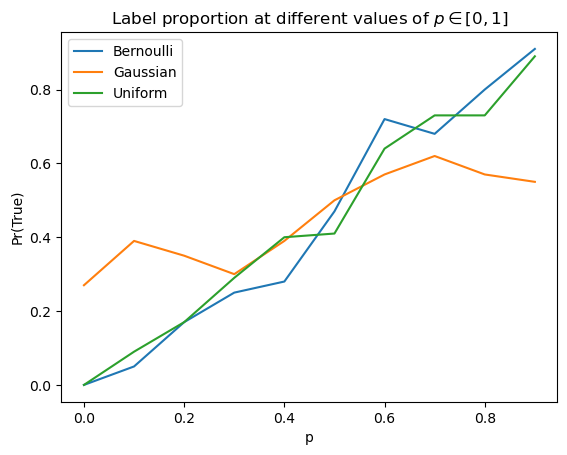

In [7]:
plt.plot(p_vals, b_vals)
plt.plot(p_vals, g_vals)
plt.plot(p_vals, u_vals)
plt.xlabel('p')
plt.ylabel('Pr(True)')
plt.title('Label proportion at different values of $p\in[0,1]$')
plt.legend(['Bernoulli','Gaussian','Uniform'], loc='upper left')
plt.show()

### For this task, we have just defined functions for computing priors and for classification of the datasets.

### Task 2

In [8]:
iris=load_iris()
X=iris.data
y=iris.target
y_binary = (y == 0).astype(int)

label_priors=compute_prior(y_binary)
print("Label Prior (Pr(True)):", label_priors)

Label Prior (Pr(True)): {1: 0.3333333333333333, 0: 0.6666666666666666}


In [9]:
#predictions

def pred(X,y_original,method):
    precision,recall,f1,tpr,fpr=[],[],[],[],[]
    p_vals=np.arange(0., 1.0, 0.1)
    for p in p_vals:
        y=SporadicClassifier(p=p, method=method).predict(X)
        precision.append(precision_score(y_original,y, zero_division=0))
        recall.append(recall_score(y_original,y, zero_division=0))
        f1.append(f1_score(y_original,y, zero_division=0))
        
        tp,tn,fp,fn=0,0,0,0
        for i in range(0,len(y),1):
            if y[i]==True and y_original[i]==True:
                tp+=1
            elif y[i]==True and y_original[i]==False:
                fp+=1
            elif y[i]==False and y_original[i]==True:
                fn+=1
            else:
                tn+=1
        tpr.append(tp/(tp+fn))
        fpr.append(fp/(fp+tn))
        
    pred_df=pd.DataFrame({'p':p_vals,'Precision':precision,'Recall':recall,'f1':f1,'TPR':tpr,'FPR':fpr})
    
    #plotting P, R, C as line plots
    plt.plot(p_vals, precision)
    plt.plot(p_vals, recall)
    plt.plot(p_vals, f1)
    plt.xlabel('p')
    plt.ylabel('metrics')
    plt.title('Metrics at different values of $p\in[0,1]$')
    plt.legend(['Precision','Recall','f1'], loc='lower right')
    plt.show()
    
    #PRC curve
    AUPRC=average_precision_score(y_original, y)
    plt.plot(recall,precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title("Precision Recall Curve, AUPRC="+str(AUPRC))
    plt.show()
    
    #ROC curve
    auroc=roc_auc_score(y_original,y)
    plt.plot(fpr,tpr)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('Reciever Operator Curve, AUROC='+str(auroc))
    plt.show()
    
    return

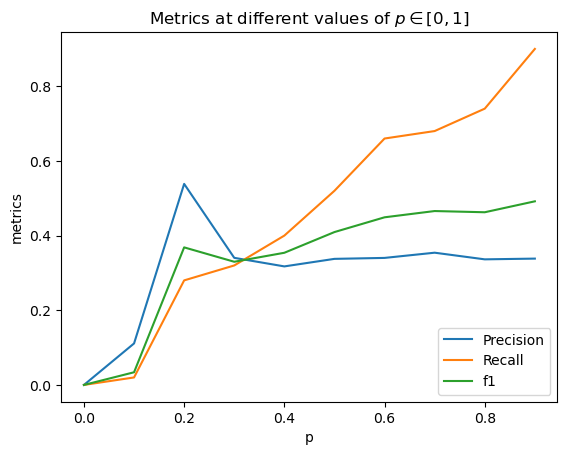

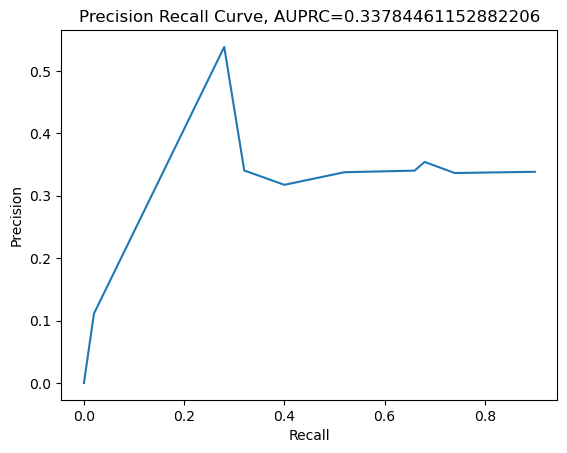

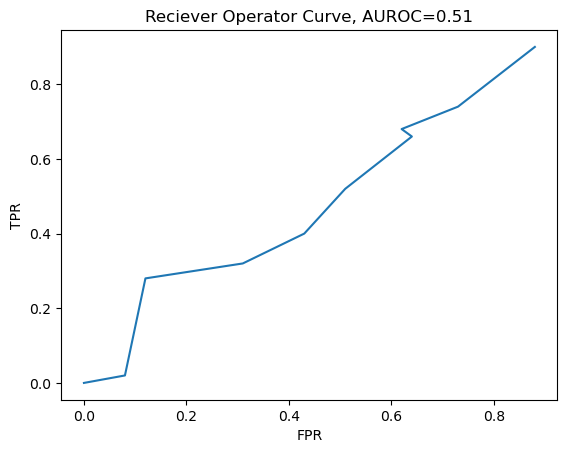

In [10]:
pred(X,y_binary,bernoulli)

### For this task, we have taken class 0 as class one and the rest two classes(1 and 2) as zero, and computed and plotted the required graphs. From the graphs, we infer that-
1. Everytime we run the code, the graphs are a bit different. This is due the fact that our classifier randomly classifies points as 0 and 1, and hence, a point classified as 1 can be classifies as 0 the next time.
2. Precision (wrt p) increases initially and then linearises. That means, value of 'p' doesnt effect the model's ability to measure the proportion of true positive predictions out of all positive predictions after a certain threshold.
3. Recall (wrt p) is a line with an increasing slope. That means as 'p' increases, model's ability of capturing positive instances increases. 
4. f1 (wrt p) hs a behaviour similar to precision curve (wrt p). Hence, after a certain threshold (around 0.3), model perrformance is not really effected by the values p. 
5. We have a low auprc (less than 0.5, around 0.35 in all cases). This indicates that our model is a poor performer. This could be due to a low precision score.
6. We have auroc values around 0.5 for all the cases. This indicates that moodel classifies at random (there is no learning of model involved). (This is an intuitive value as our classifier is a random classifier).

### Task 3

In [11]:
X=iris.data
y=iris.target

In [12]:
def dec_boundary(X,y,method):
    if method not in ["uniform_random", "bernoulli", "gaussian"]:
        raise("Not a valid method")
    p_values = np.arange(0, 1.25, 0.25)
    cmap = ListedColormap(['#98FB98', '#4682B4'])
    norm=colors.BoundaryNorm([0,0.5,1],cmap.N)

    plt.figure(figsize=(15, 12))
    for i, p in enumerate(p_values):
        clf = SporadicClassifier(method=method, p=p)
        y_hat=clf.predict(X)
        clf.fit(X, y_hat) #for convention
        xx, yy = np.meshgrid(np.arange(X[:, 0].min() - 1, X[:, 0].max() + 1, 0.01),
                                np.arange(X[:, 1].min() - 1, X[:, 1].max() + 1, 0.01))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.subplot(3, 2, i + 1)
        plt.contourf(xx, yy, Z, cmap=cmap,norm=norm, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y,cmap=cmap, edgecolor='k', s=25)
        plt.title('Method: {}, p = {}'.format(method,p))
        plt.xlabel("feature 1")
        plt.ylabel("feature 2")
    
    plt.tight_layout()
    plt.show()


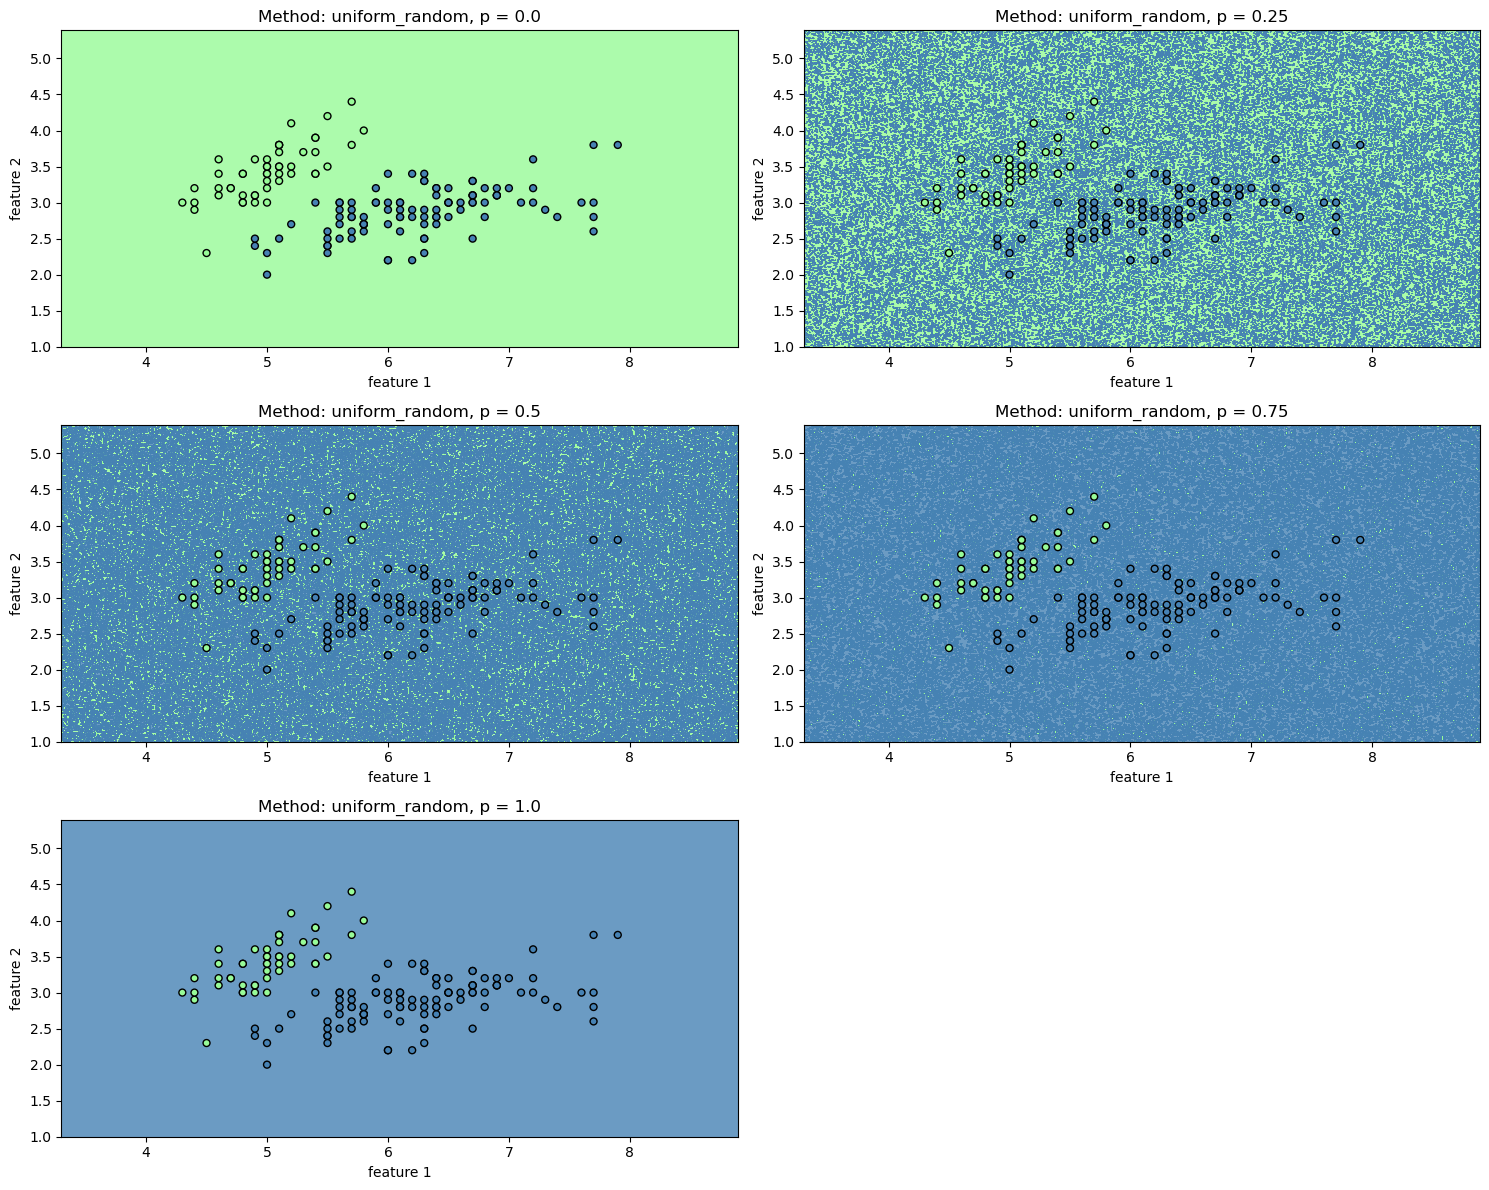

In [13]:
dec_boundary(X,y,"uniform_random")

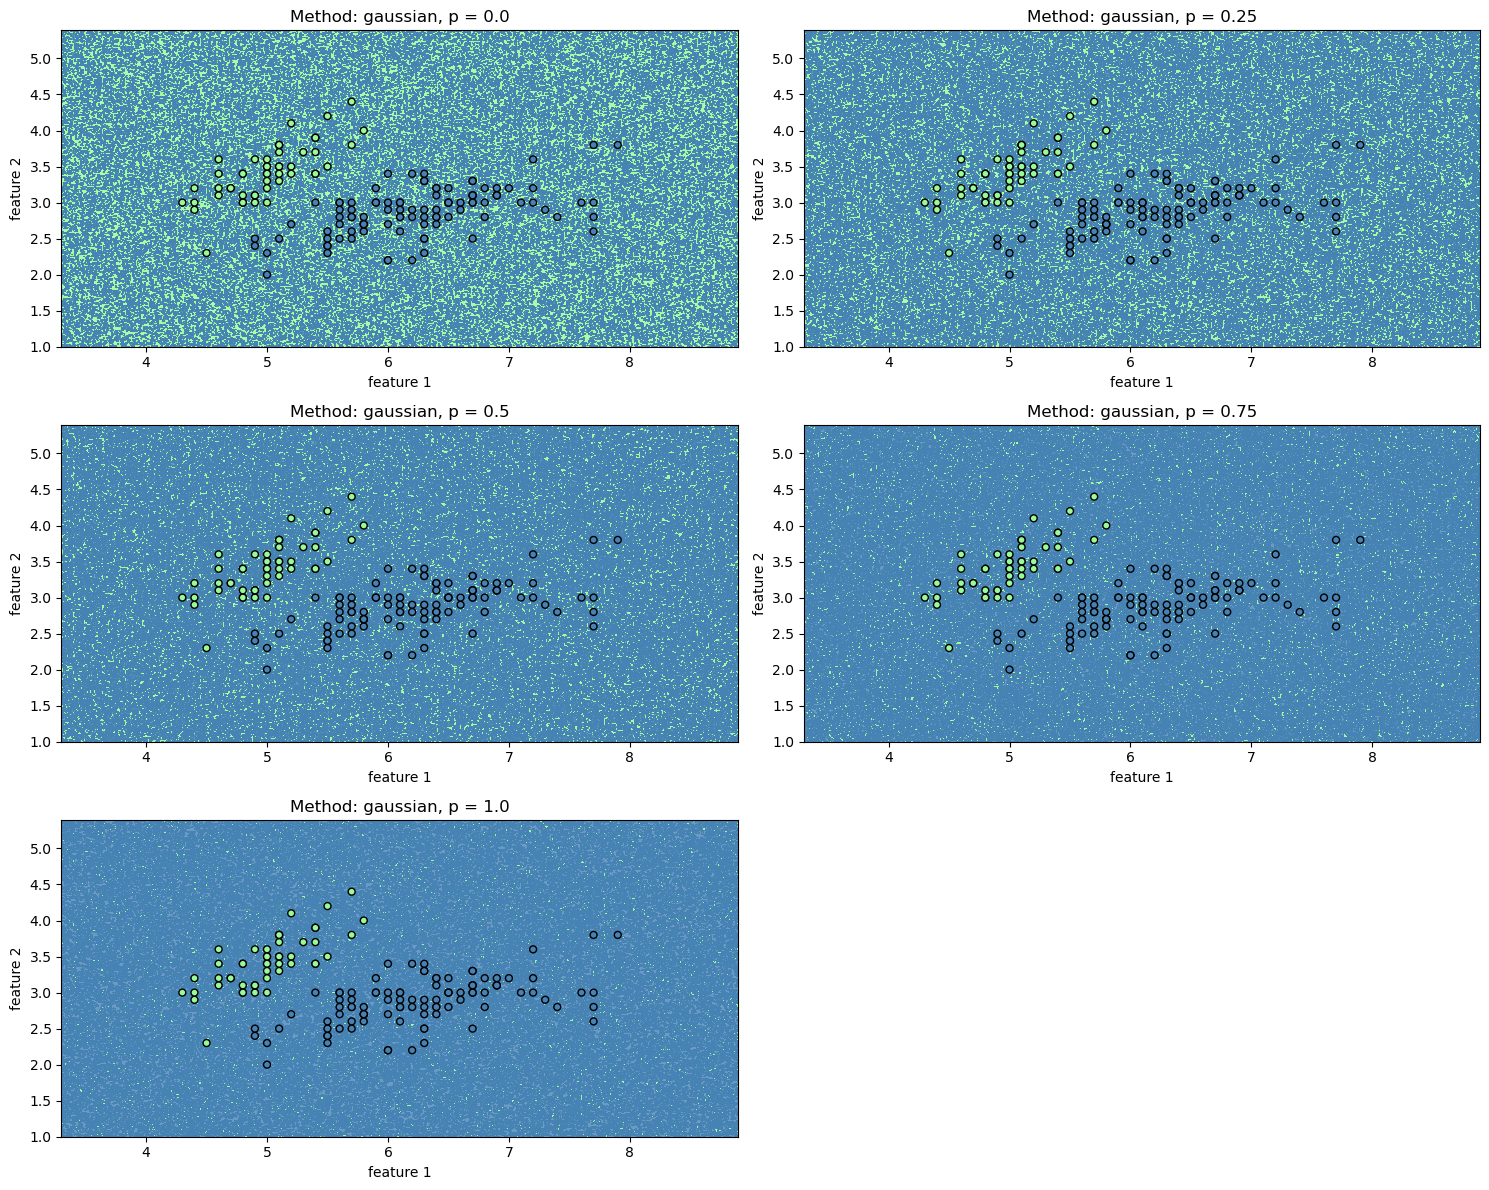

In [14]:
dec_boundary(X,y,"gaussian")

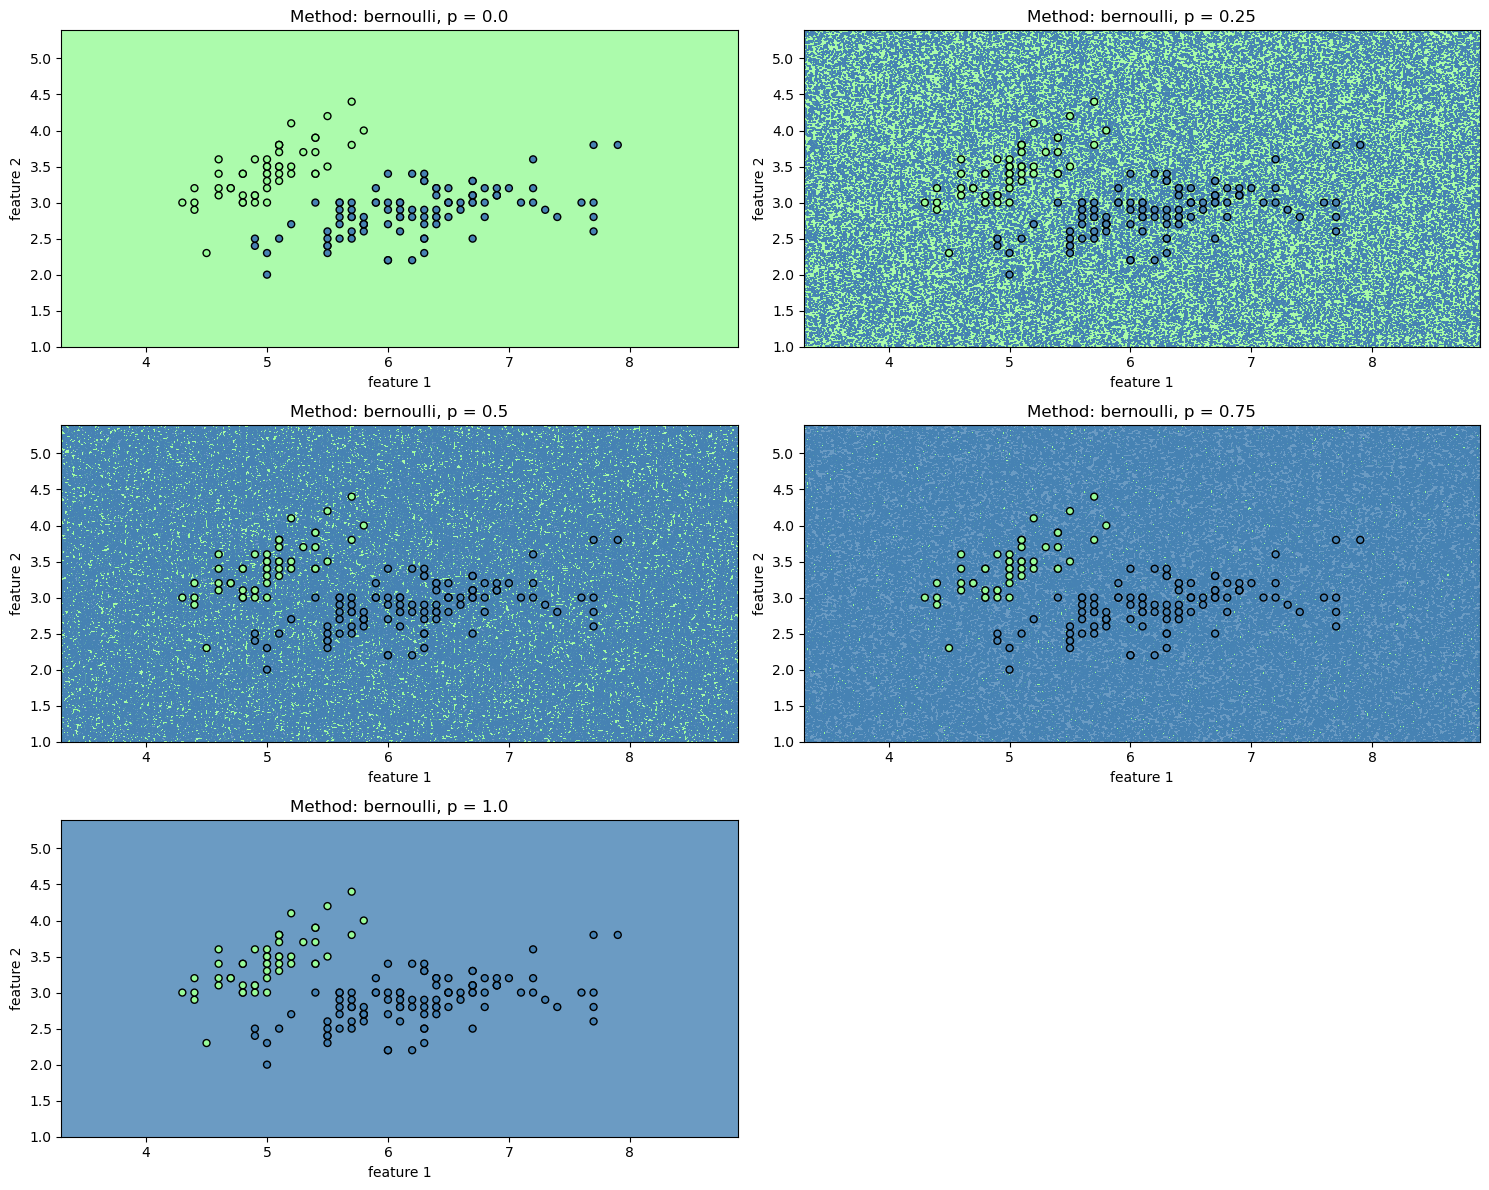

In [15]:
dec_boundary(X,y,"bernoulli")

### The decision boundaries are poorly defined for all values of p and distibutions.
1.From graphs for bernoulli and uniform distribution, we can see that for p=0 and 1, model has no discriminative power and predictions are all class 1 (or 0). For p = 0.25, 0.5 and 0.75, the model has a slightly better discriminative power. 
2. For gaussian, the ditribution of predictions is same, the model has some amount of discriminatory power for all values of p. However, for p=0 and 1, the power to classify is still low as compared to the other p values. 